# AG-HYPOPT · Trial 15

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Fourteen trials recorded, objective order: trial_09 0.1657 (BEST), trial_14 0.1679, trial_05 0.1863, trial_11 0.1883, trial_01 0.1907, trial_07 0.1940, trial_12 0.1941, trial_13 0.1941, trial_08 0.1948, trial_04 0.1987, trial_02 0.2075, trial_06 0.2203, trial_03 0.2472, trial_10 0.3727 (worst). Recap: mu_fit is pinned at ~half of mu_true for every config (objective floor); the objective is the gamma term, dominated by low transmission, and it is unstable. The campaign sweet spot is now identified: an interior region of high sigma_ref (~22-25), low-to-mid lr_mu (~5.5-6.5), high lr_gamma (~0.88-0.90) and moderate anneal (~0.41-0.62) -- trial_09 (0.1657) and trial_14 (0.1679) are two consistent good draws there, both partly rescuing low-transmission gamma. Configs pushing these knobs to boundaries have blown up (trial_10). TPE (14/5) is exploiting. Context only.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_15'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (14/5 trials)
ID |     ei | params
 1 | 2.6617 | {"gamma_anneal": 0.6856021543511059, "lr_gamma": 0.8581865905461951, "lr_mu": 5.0, "sigma_ref": 13.759247055823952}
 2 | 3.2499 | {"gamma_anneal": 0.7122349225771086, "lr_gamma": 0.9093620644466098, "lr_mu": 5.0, "sigma_ref": 22.783678117837226}
 3 | 2.7441 | {"gamma_anneal": 0.5459045426561442, "lr_gamma": 0.9426224374220493, "lr_mu": 6.014469257245988, "sigma_ref": 18.507767060887172}
 4 | 3.3048 | {"gamma_anneal": 0.6759325591697529, "lr_gamma": 0.8672669318304013, "lr_mu": 5.0, "sigma_ref": 22.13897067193968}
 5 | 2.4054 | {"gamma_anneal": 0.1851523445668436, "lr_gamma": 0.8641964710002275, "lr_mu": 7.8802590919640405, "sigma_ref": 11.857379966681512}
 6 | 1.6655 | {"gamma_anneal": 0.6874924692227139, "lr_gamma": 0.9413005854809281, "lr_mu": 12.657777820249546, "sigma_ref": 20.45997004416186}
 7 | 3.3183 | {"gamma_anneal": 0.75, "lr_gamma": 0.8763973334233128, "lr_mu": 5.0, "sigma_ref": 25.0}
 8 | 3.4275 | {"gamma_ann

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

TPE (14/5) ranks by expected improvement. The highest-EI candidate is candidate 8 (EI 3.43): gamma_anneal 0.456, lr_gamma 0.912, lr_mu 5.0, sigma_ref 22.0 -- which sits squarely in the campaign sweet spot (trial_09/trial_14: high sigma_ref ~22-25, low lr_mu ~5.7-6.5, high lr_gamma ~0.88-0.90, moderate anneal ~0.41-0.62). The runner-ups (candidates 7, 4, 2: EI 3.32/3.30/3.25) are similar but push anneal or sigma_ref further toward or onto boundaries (candidate 7 has both gamma_anneal 0.75 and sigma_ref 25.0 at bounds). The top-EI pick is the cleanest interior continuation of the region that has produced the two best trials, so I follow it. I choose candidate 8.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 8               # highest-EI TPE pick, inside the campaign sweet spot


chosen: {'gamma_anneal': 0.45648111356308096, 'lr_gamma': 0.911928901523244, 'lr_mu': 5.0, 'sigma_ref': 21.996027046958904}
Running  1nW Trans05 ... 

μ 9.39 -> 4.70 | γ 8.5 -> 0.85 | NLL 1.29


Running  1nW Trans20 ... 

μ 17.32 -> 8.66 | γ 8.5 -> 9.55 | NLL 3.37


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 51.19 | γ 14.1 -> 13.70 | NLL 3.00


Running 3nW Trans100 ... 

μ 175.71 -> 87.09 | γ 14.1 -> 13.94 | NLL 3.43



Total: 2.4 min


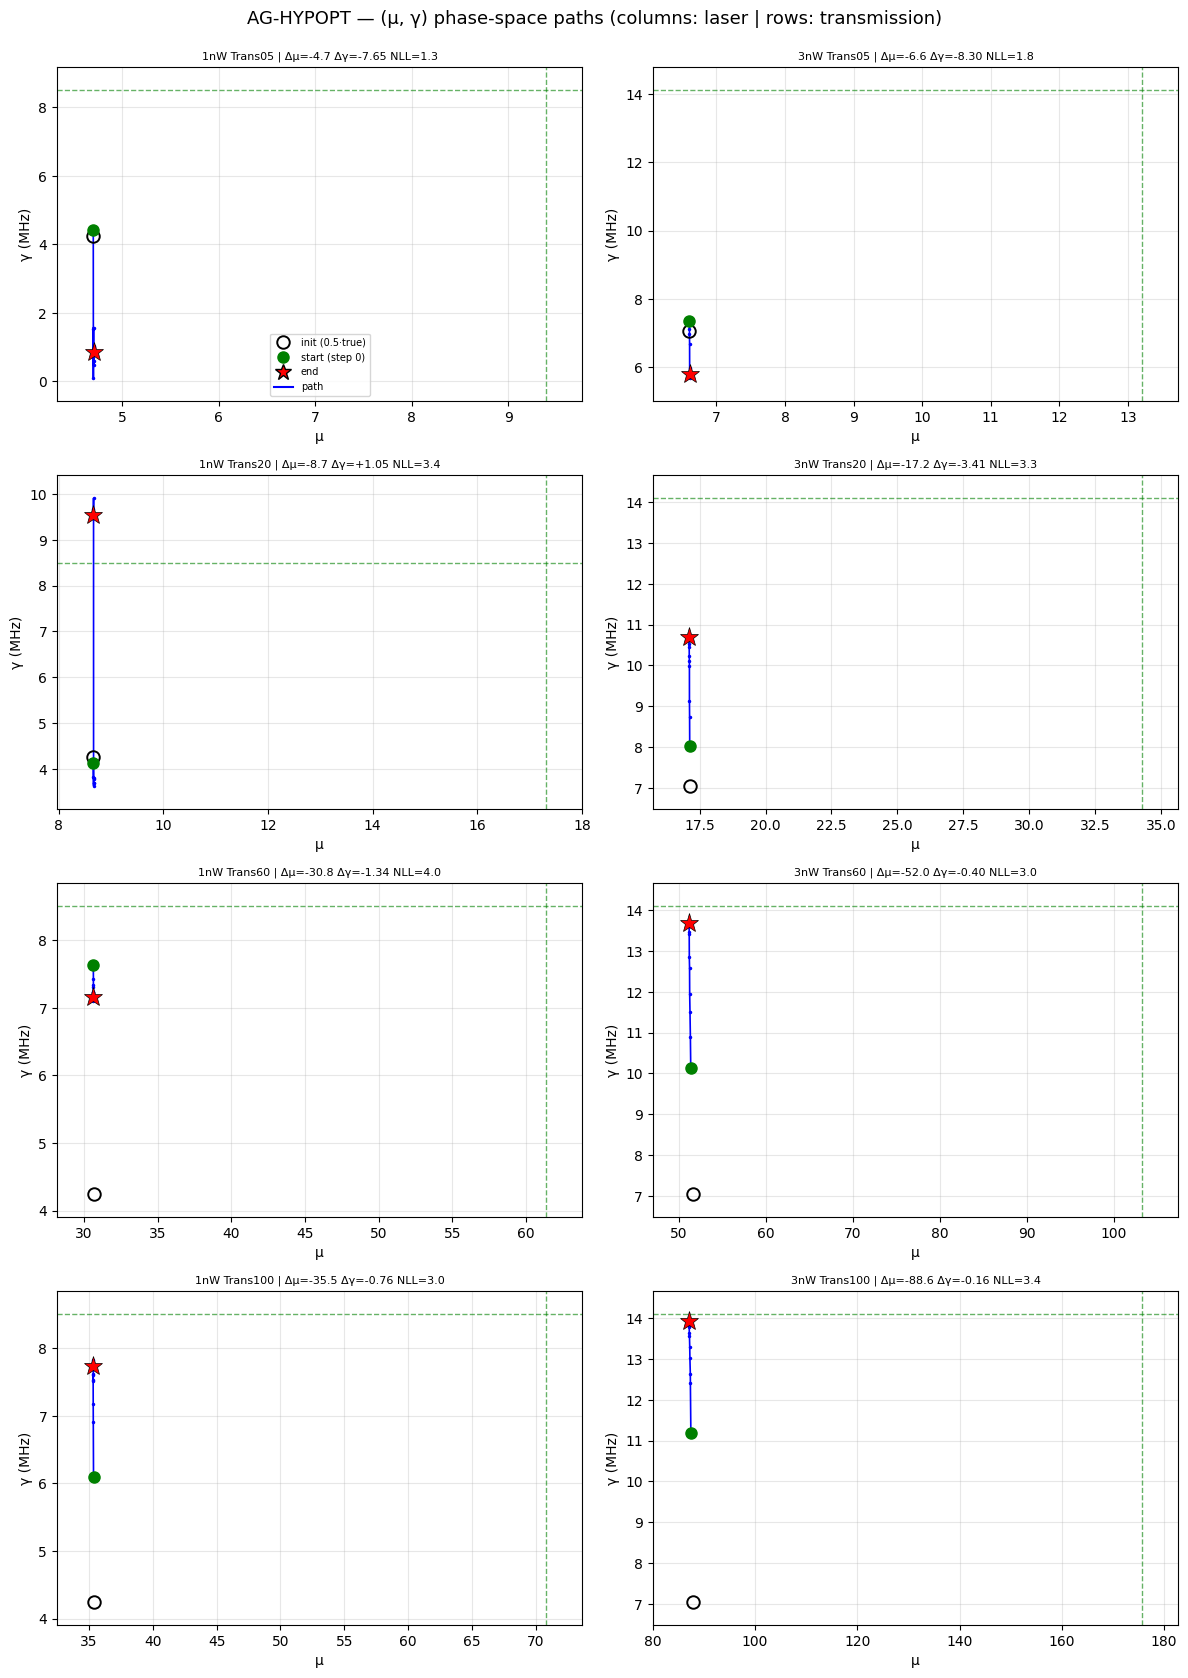

trial finished in 2.5 min
objective = 0.2046 ± 0.0507
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    4.70   -49.9 |     8.50    0.85   -90.0
1nW Trans20    17.32    8.66   -50.0 |     8.50    9.55   +12.4
1nW Trans60    61.37   30.62   -50.1 |     8.50    7.16   -15.8
1nW Trans100   70.82   35.34   -50.1 |     8.50    7.74    -8.9
3nW Trans05    13.20    6.61   -49.9 |    14.10    5.80   -58.9
3nW Trans20    34.28   17.10   -50.1 |    14.10   10.69   -24.2
3nW Trans60   103.20   51.19   -50.4 |    14.10   13.70    -2.8
3nW Trans100  175.71   87.09   -50.4 |    14.10   13.94    -1.2

μ: RMSE 40.618 (rel 50.1%, bias -30.496) | γ: RMSE 4.223 (rel 39.8%, bias -2.621)


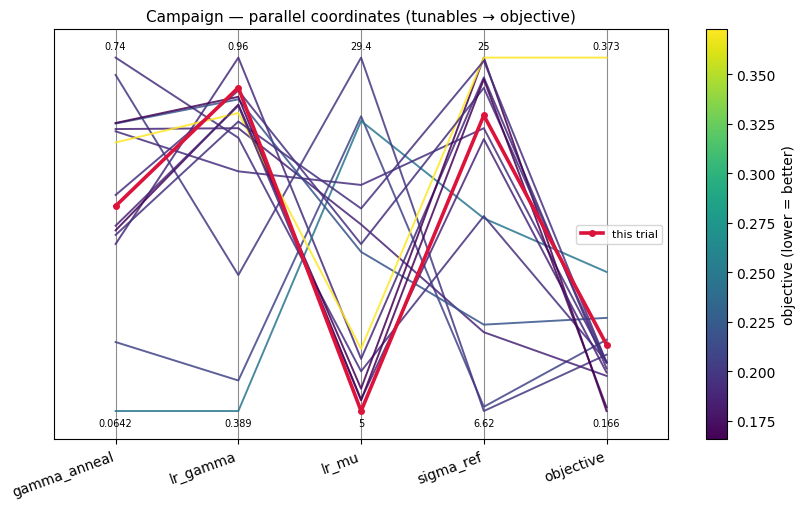

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 15, tenth TPE-driven trial; highest-EI pick, inside the sweet spot: sigma_ref 22.0, lr_mu 5.0, lr_gamma 0.912, gamma_anneal 0.456. Result: objective 0.2046 +/- 0.0507, clearly worse than the trial_09/trial_14 sweet-spot draws (0.1657/0.1679) despite the similar region; runtime 2.5 min. mu_fit is unchanged at a uniform ~half-truth (Delta-mu% -49.9 to -50.4; mu RMSE 40.62, relative 50.1%). gamma_fit broke at 1 nW Trans05, collapsing to -90.0% (0.85 vs 8.50 MHz), while high transmission stayed fine (3 nW Trans60/100: -2.8/-1.2%) and 1 nW Trans20 overshot (+12.4%); gamma RMSE 4.22 (relative 39.8%). So a config in the same sweet-spot neighbourhood produced a third distinct gamma outcome, with only the lr_mu pushed to the 5.0 boundary.

**Summary:** Trial 15 (sigma_ref 22.0, lr_mu 5.0, lr_gamma 0.912, gamma_anneal 0.456) -> objective 0.2046 +/- 0.0507; inside the sweet-spot region but 1 nW Trans05 gamma collapsed to -90%, degrading the objective.
**Key insight:** Even within the sweet-spot band the low-transmission gamma can collapse outright (here 1 nW Trans05 to 0.85 MHz), so the region is good on average but not robust -- the instability, not the mean of any knob, sets each trial's score.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
No new structural notes; the real-data attractor note from trial_01 still stands.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 15 (sigma_ref 22.0, lr_mu 5.0, lr_gamma 0.912, gamma_anneal 0.456): objective 0.2046 +/- 0.0507; inside the sweet-spot region but 1 nW Trans05 gamma collapsed to -90%'
KEY_INSIGHT = 'Even within the sweet-spot band the low-transmission gamma can collapse outright (1 nW Trans05 to 0.85 MHz), so the region is good on average but not robust -- the low-T instability, not any knob mean, sets each trial score.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_15 | current best: trial_09


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_16.ipynb. Open it and follow its cells from the top.
